# Alpha Sweep Experiment Analysis
Analysis of how the `alpha` hyperparameter affects metrics (deletion ratio, TVD, marginal error, runtime, loss, ML accuracy) across different datasets and algorithms.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load aggregated data
df = pd.read_csv('../experiment_results_summary.csv')

# Filter for alpha sweep batch may2026
df = df[df['experiment_name'].str.startswith('alpha_sweep_may2026', na=False)].copy()

# Map new flattened column names to expected shorter names
rename_map = {
    'meta_repairer_params_use_marginals': 'use_marginals',
    'meta_repairer_params_alpha': 'alpha',
    'meta_obtainer_params_k': 'k',
    'meta_obtainer_params_selection_budget': 'sel_budget',
    'meta_obtainer_params_generation_budget': 'gen_budget',
    'meta_synthesizer_params_seed': 'seed',
    'meta_synthesizer_params_size': 'iters'
}
df = df.rename(columns=rename_map)

# Clean up names
df['repairer'] = df['repairer'].str.replace('Repairer', '').str.replace('VC', '-VC')
df.loc[df['use_marginals'] == True, 'repairer'] = df['repairer'] + ' (Marginals)'
df['engine'] = df['engine'].fillna('CoNoise')

print(f"Total New Alpha Sweep records: {len(df)}")
print("Unique Experiment Names found:", df['experiment_name'].unique()[:5], "...")
print("Records by Dataset:", df.groupby('dataset').size().to_dict())
print("Records by Repairer:", df.groupby('repairer').size().to_dict())


Total New Alpha Sweep records: 505
Unique Experiment Names found: ['alpha_sweep_may2026_adult_aim_classic_vc_a0.0'
 'alpha_sweep_may2026_adult_aim_classic_vc_a0.01'
 'alpha_sweep_may2026_adult_aim_classic_vc_a0.02'
 'alpha_sweep_may2026_adult_aim_classic_vc_a0.03'
 'alpha_sweep_may2026_adult_aim_classic_vc_a0.04'] ...
Records by Dataset: {'adult': 121, 'census': 139, 'compas': 124, 'tax': 121}
Records by Repairer: {'Classic-VC': 160, 'ILP (Marginals)': 26, 'Vanilla-VC': 159, 'Weighted-VC': 160}


## Visualizing Metrics vs. Alpha


Dataset: ADULT



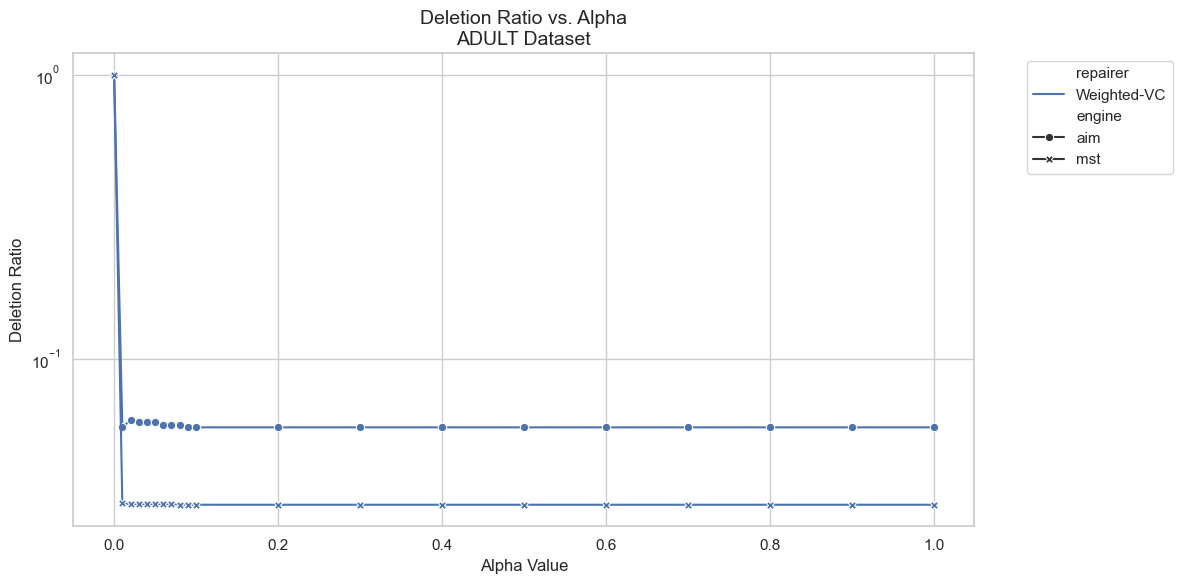

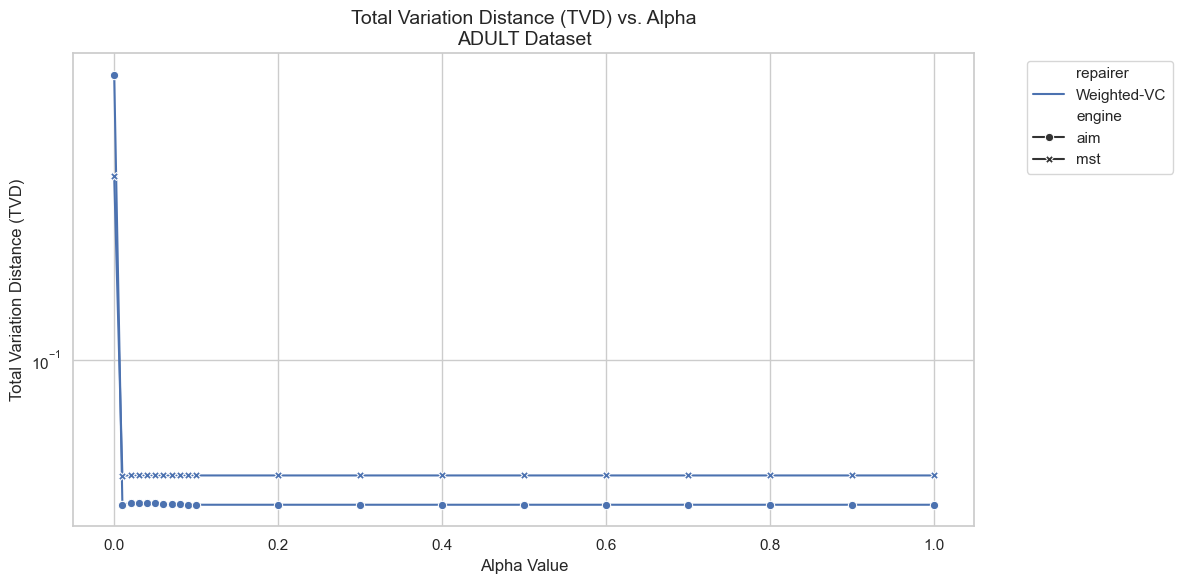

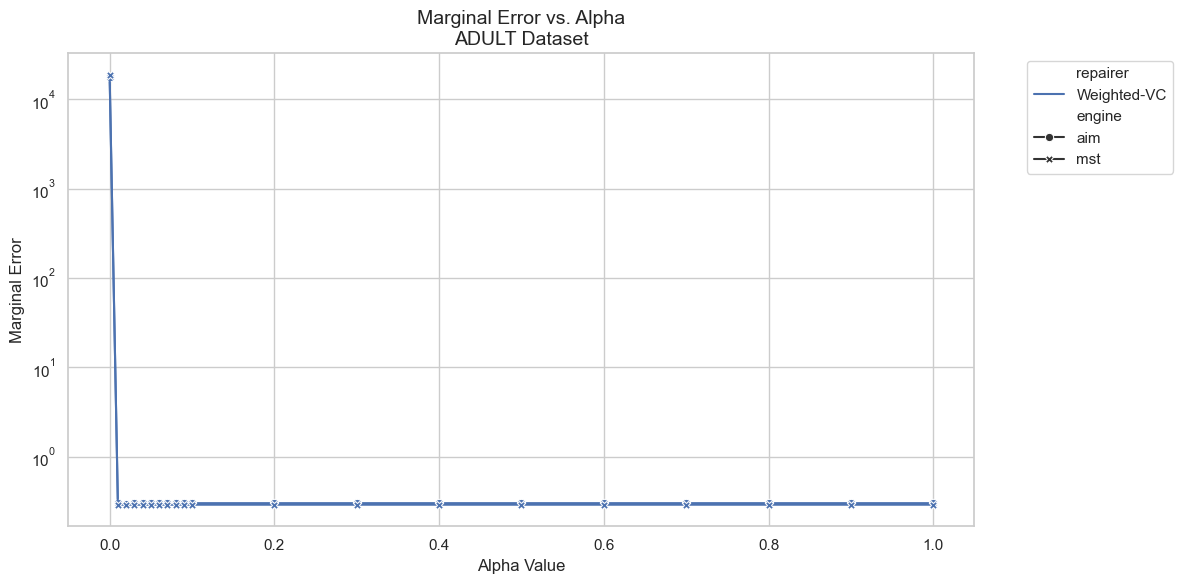

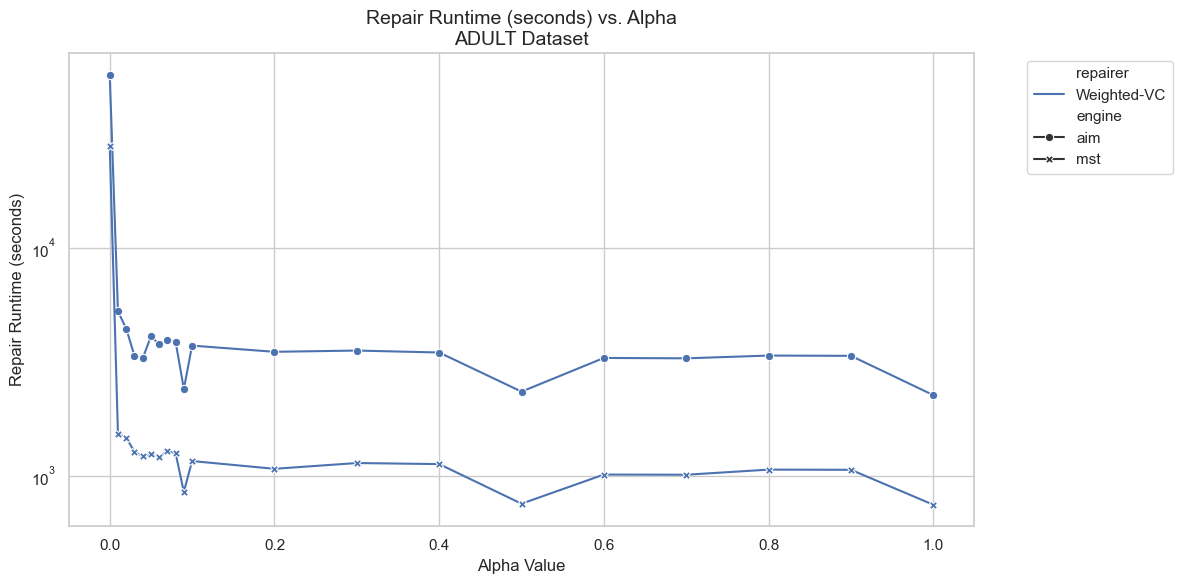

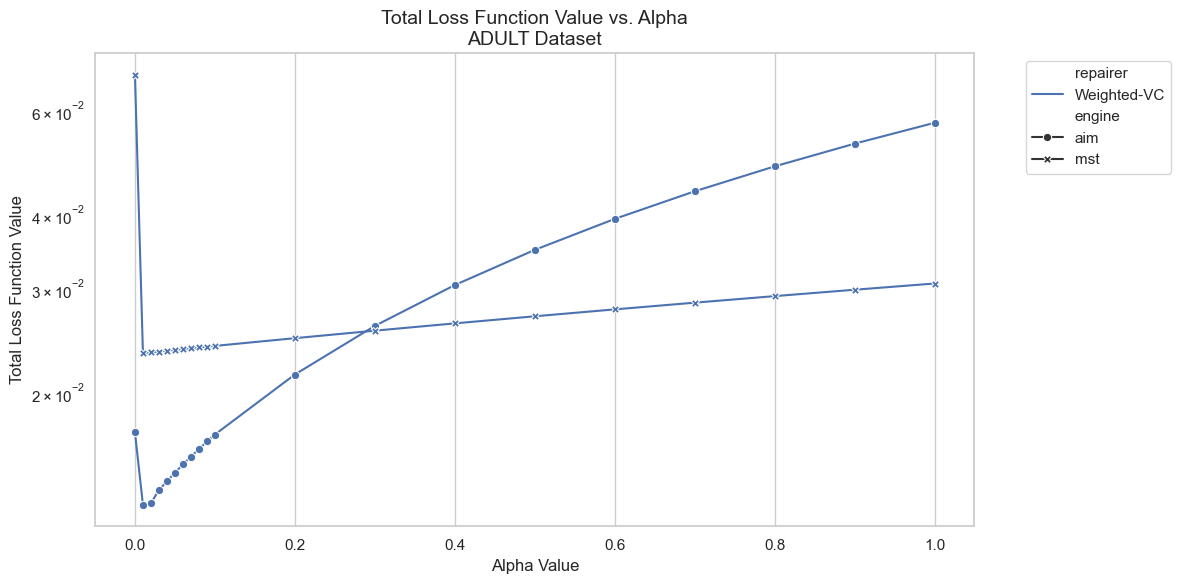

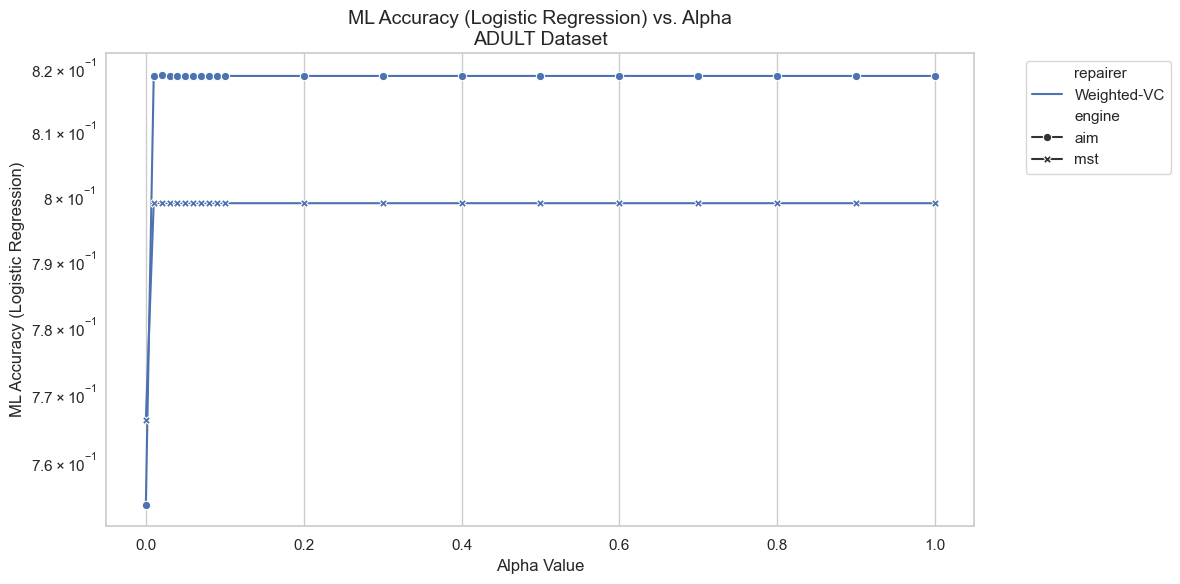


Dataset: CENSUS



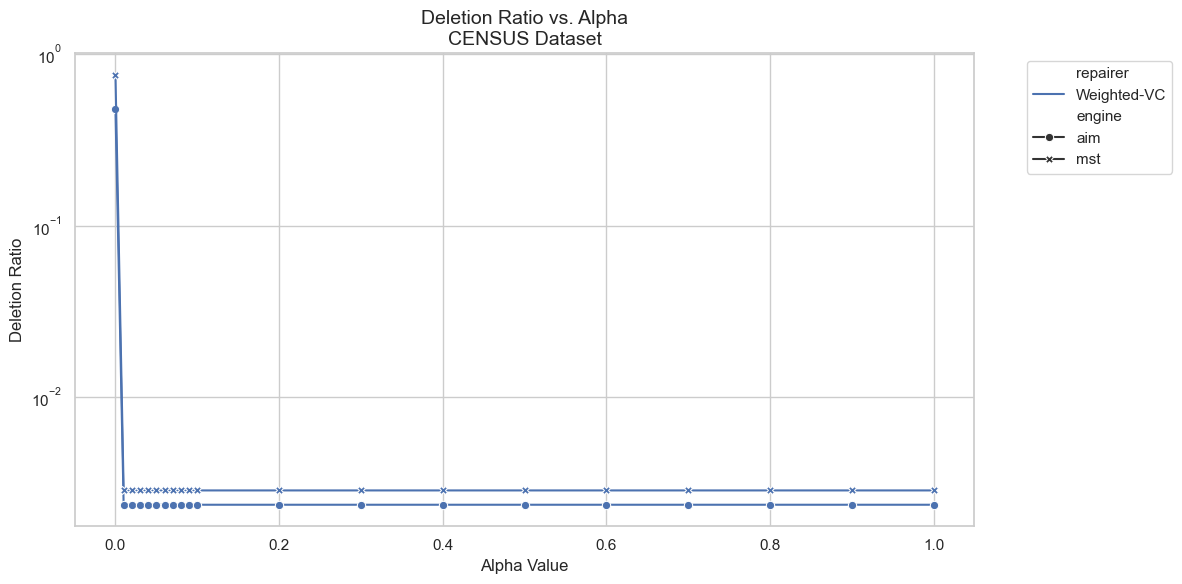

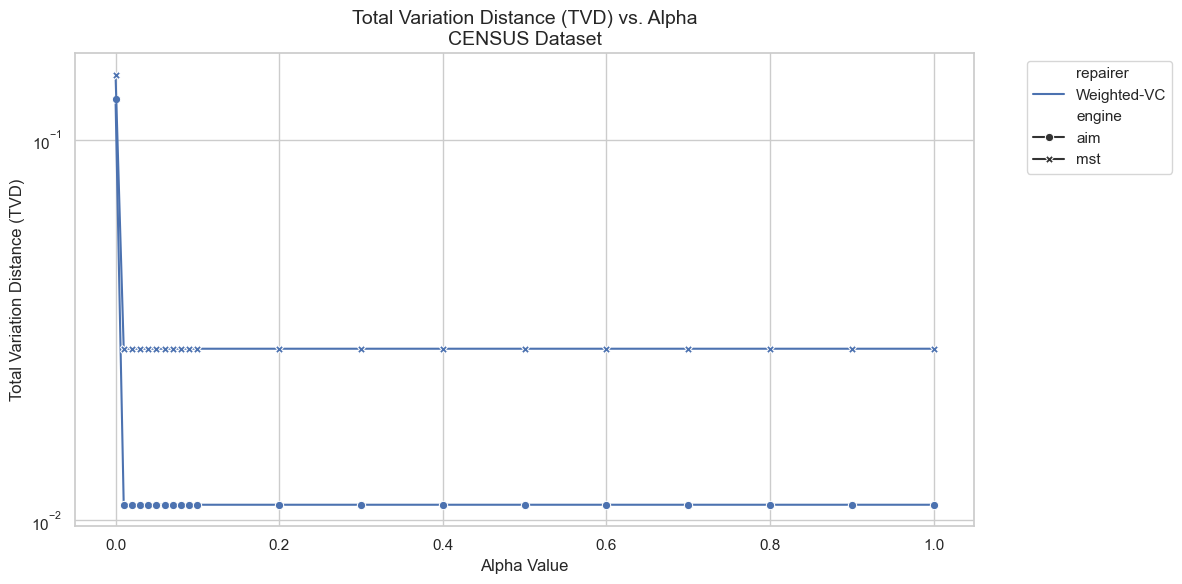

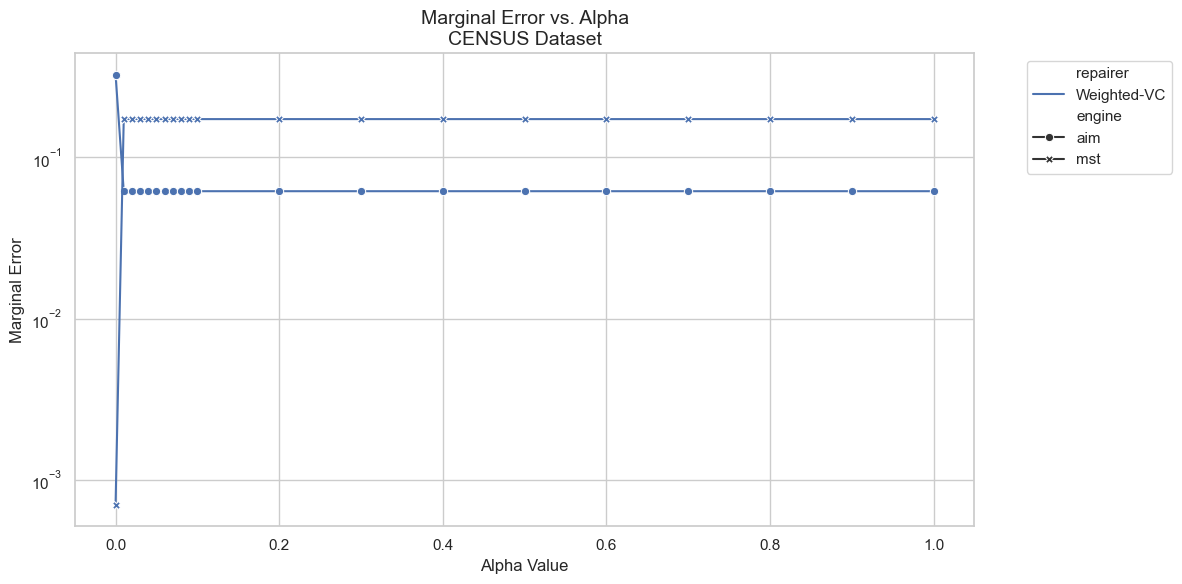

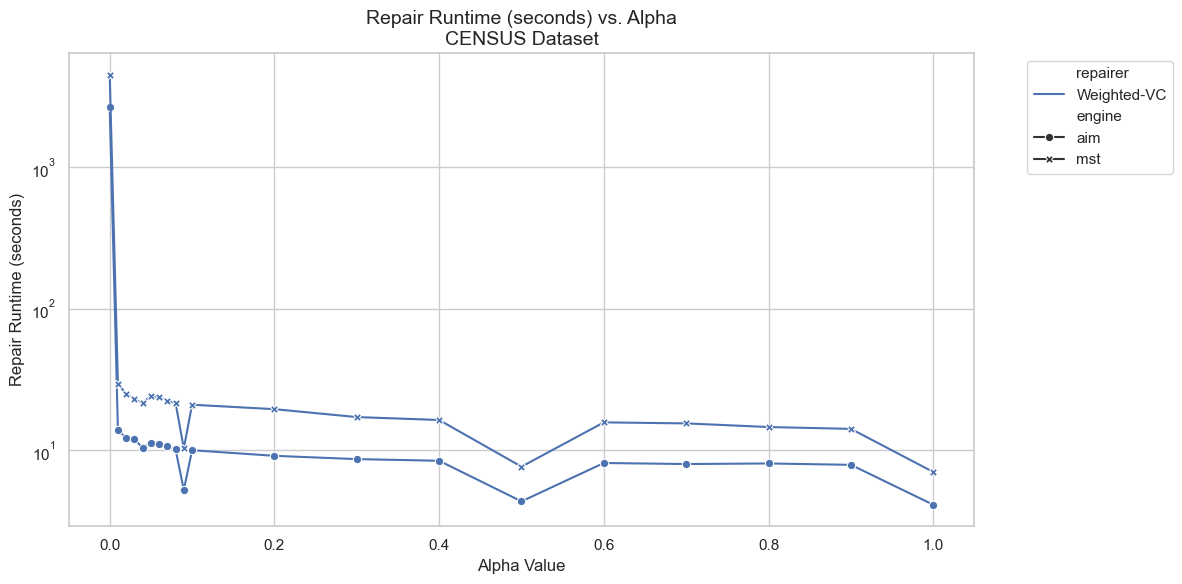

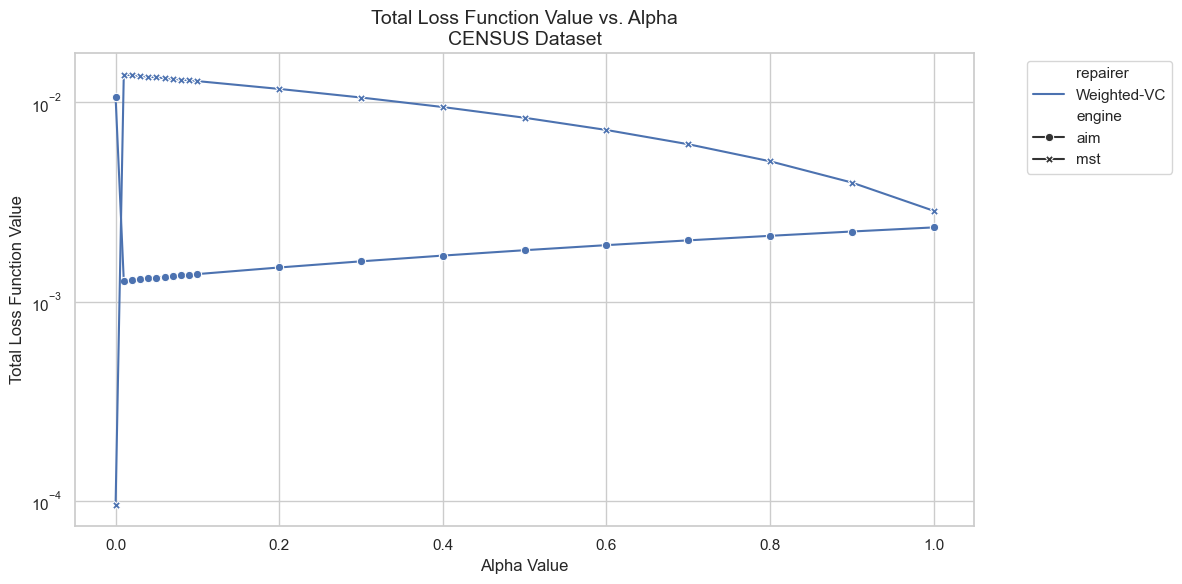

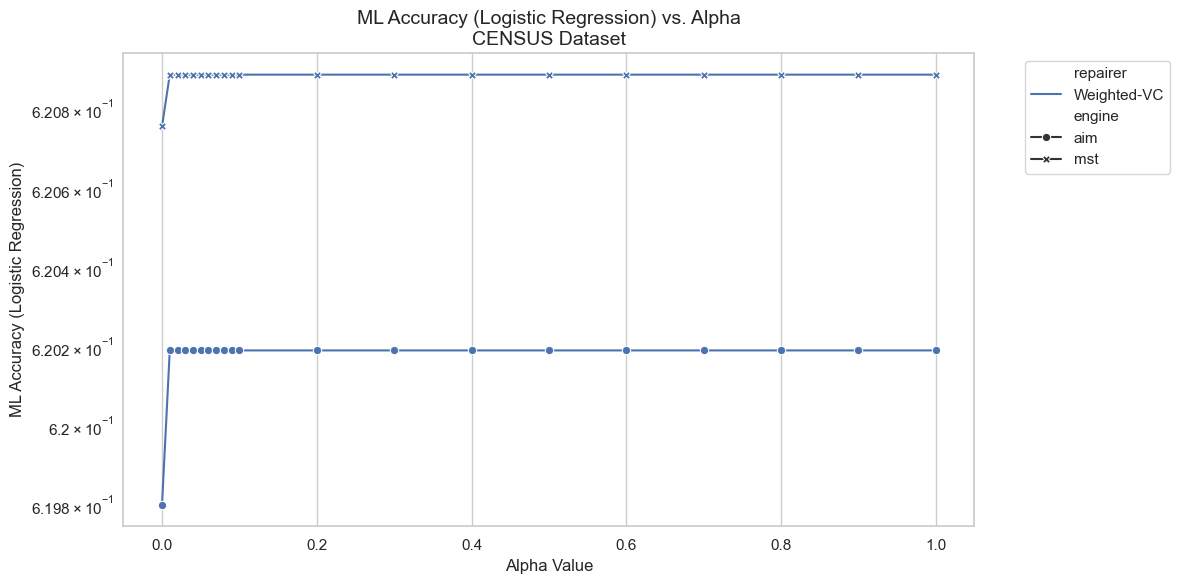


Dataset: COMPAS



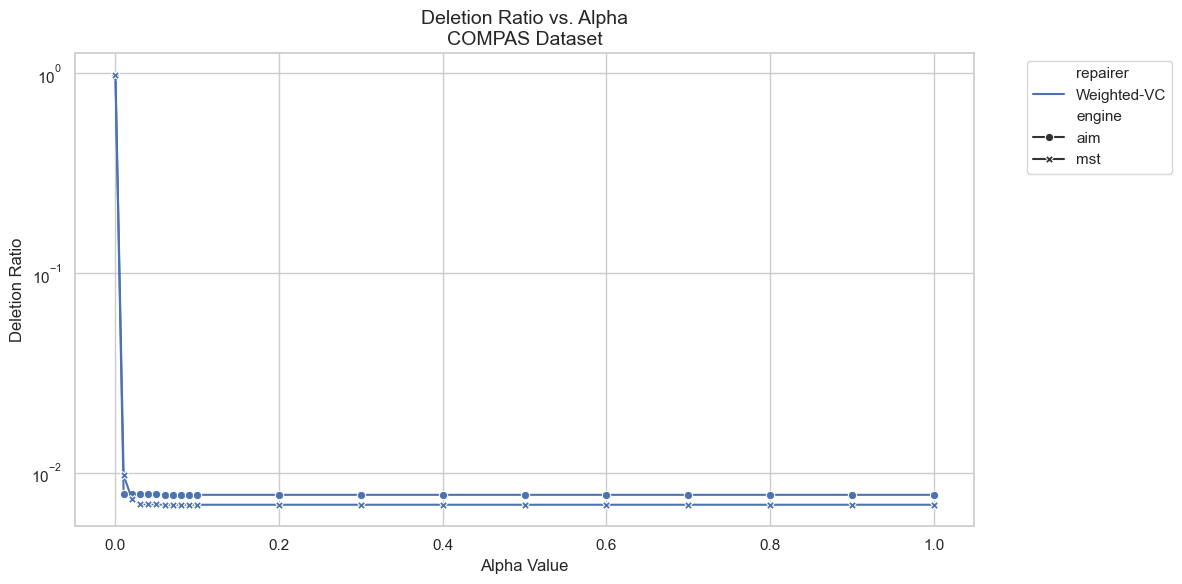

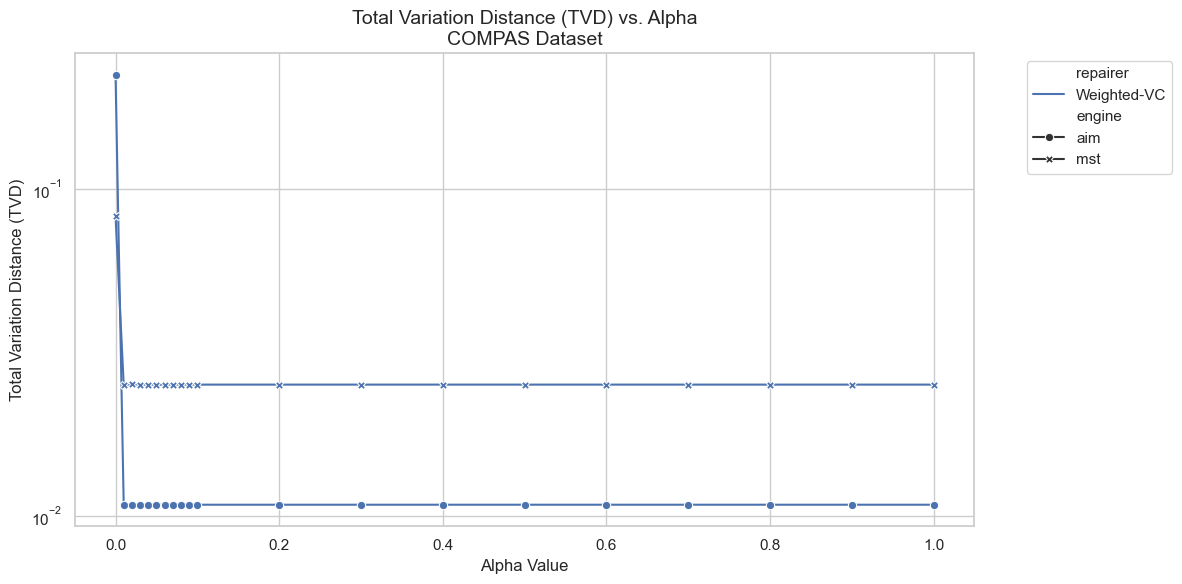

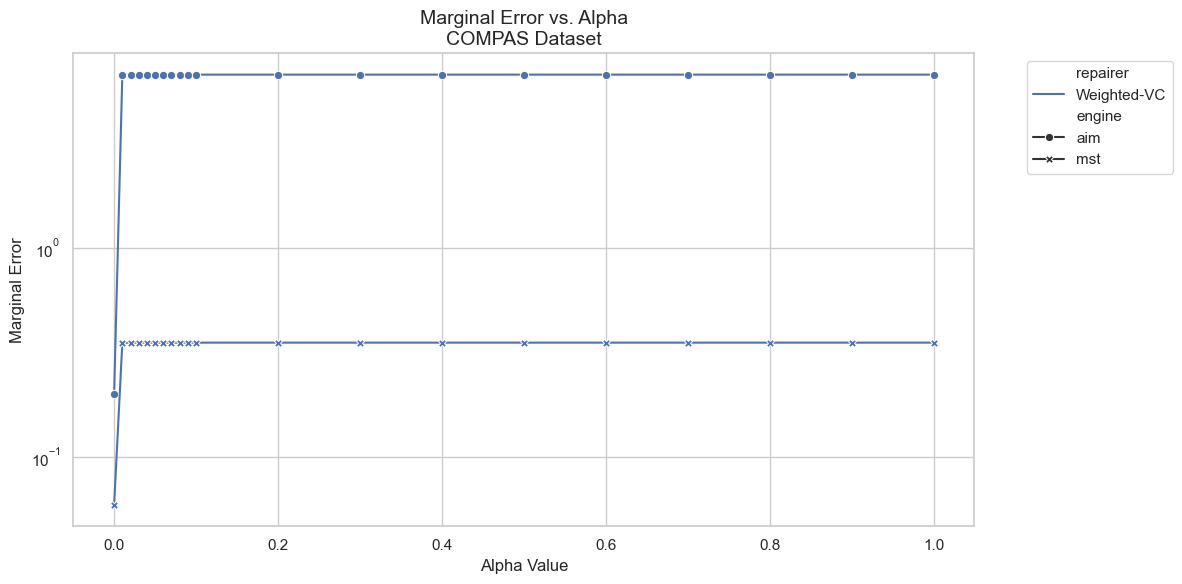

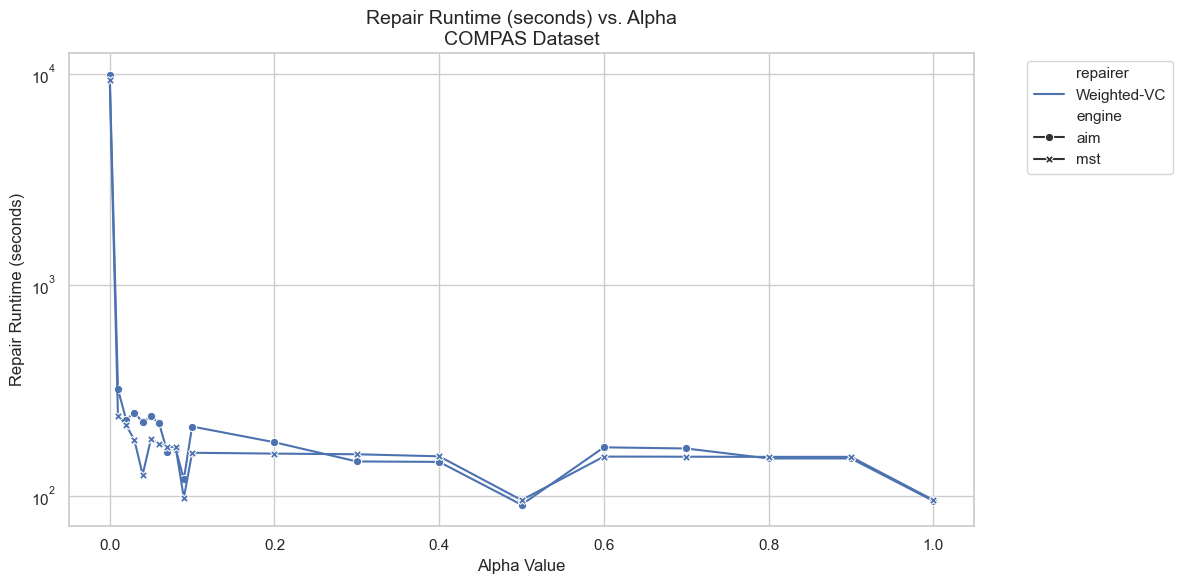

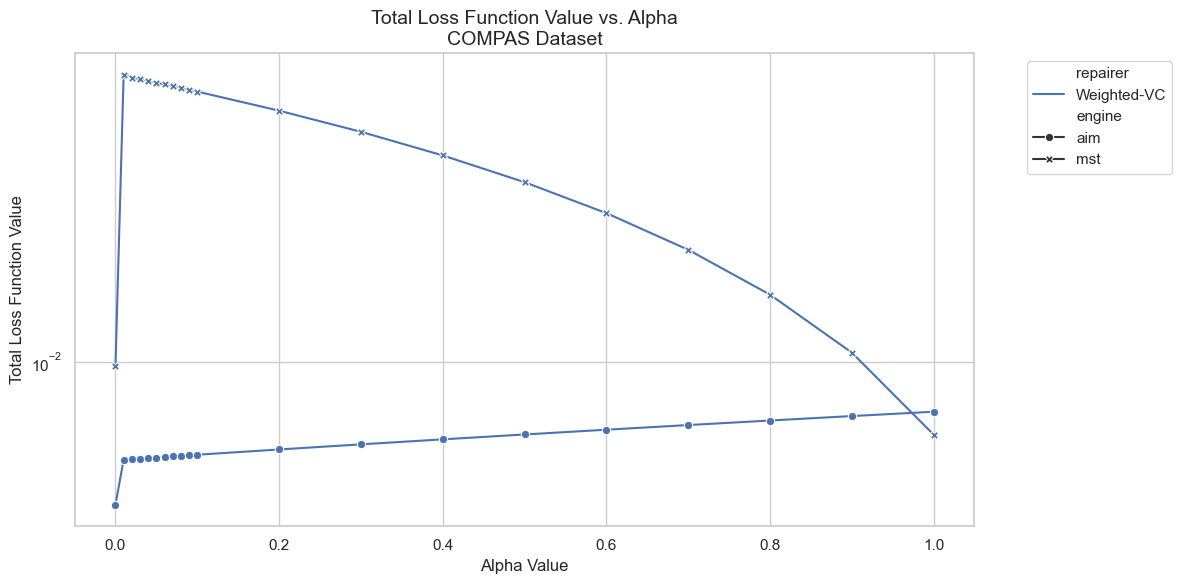

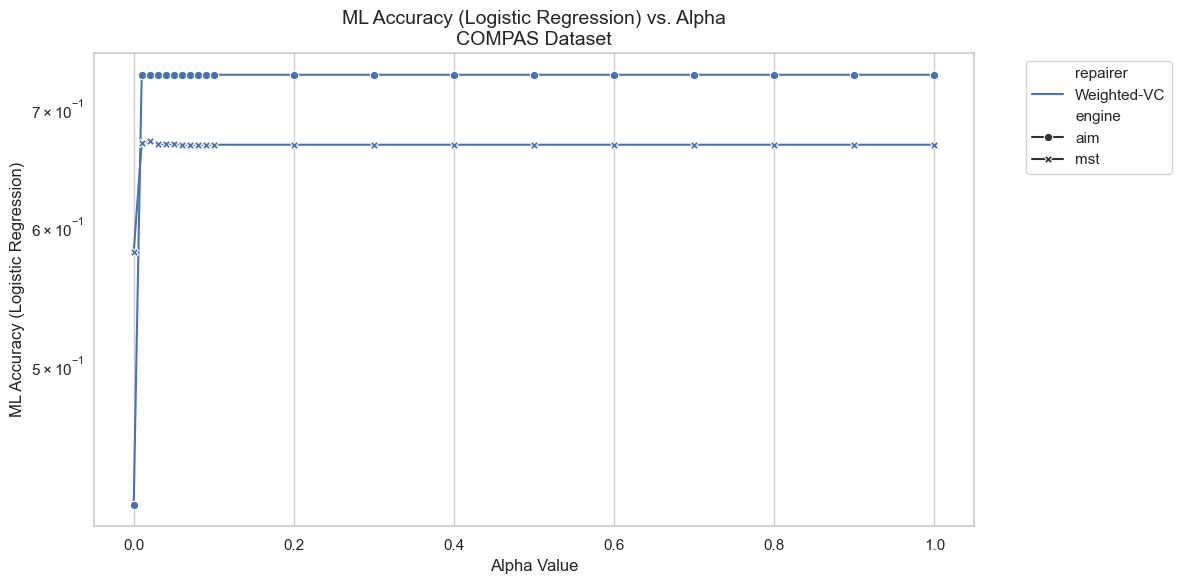


Dataset: TAX



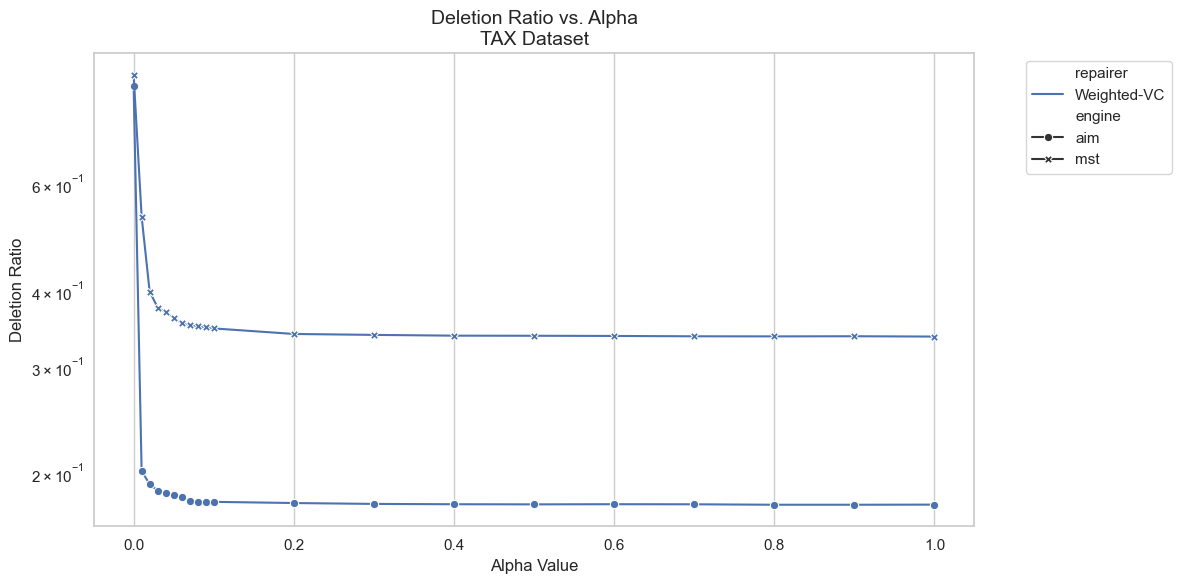

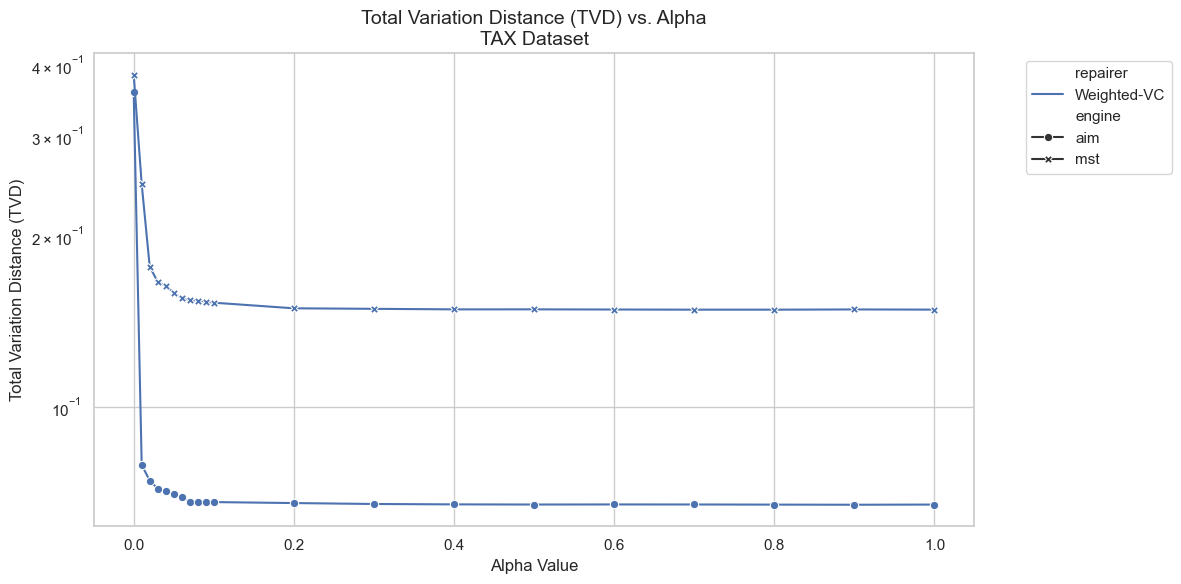

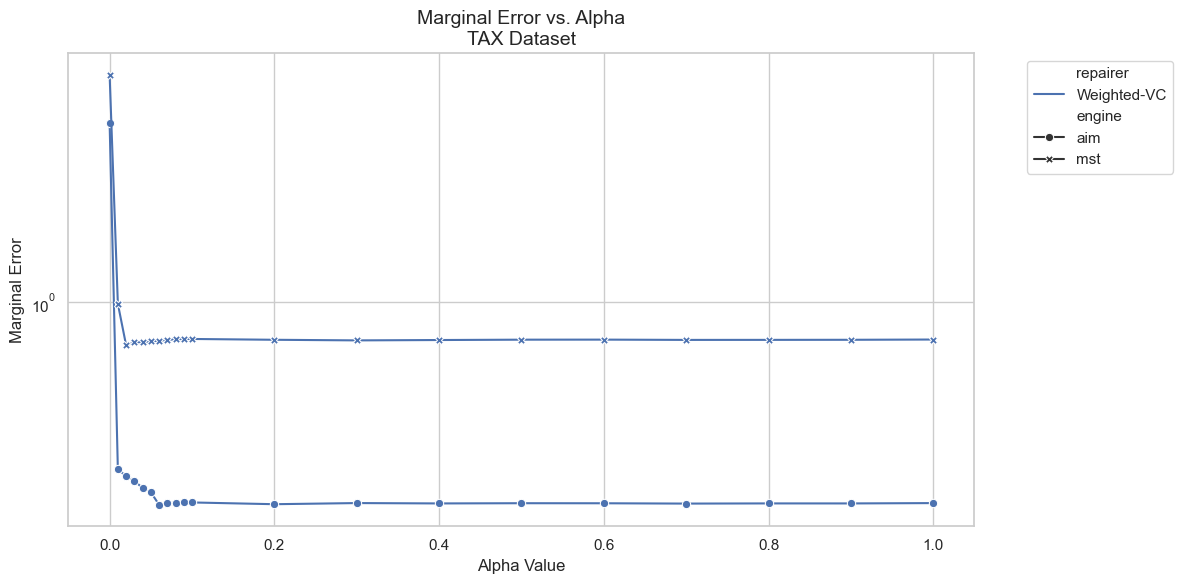

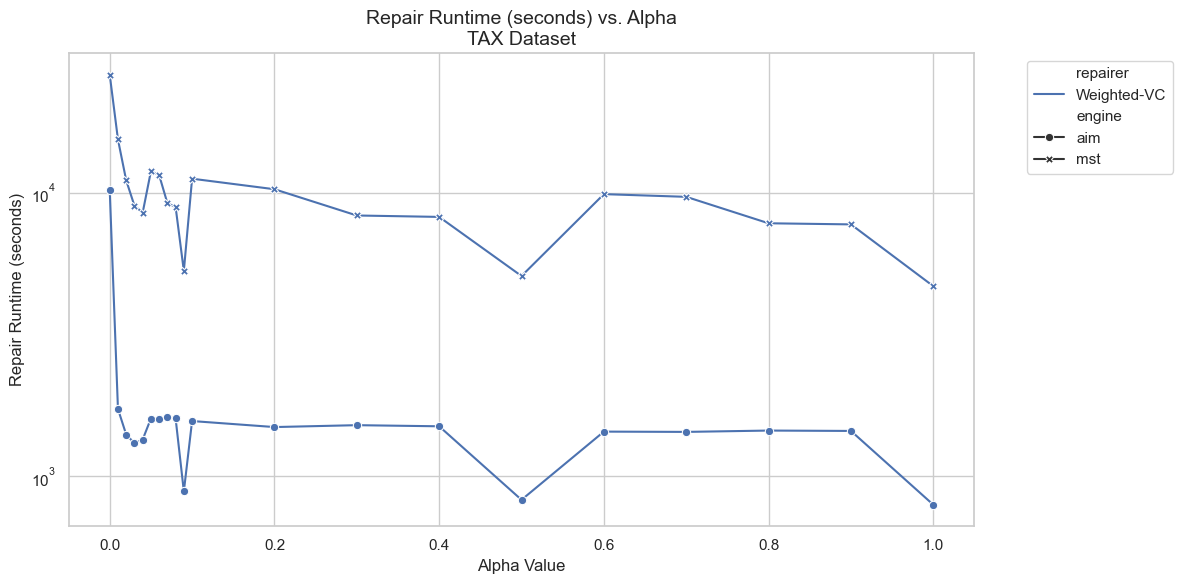

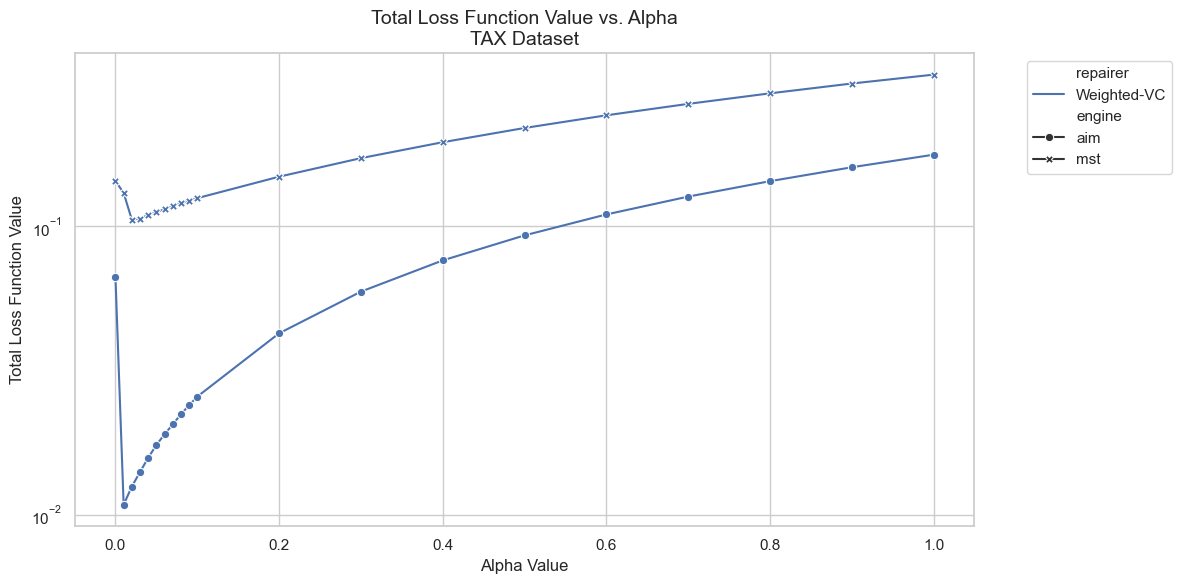

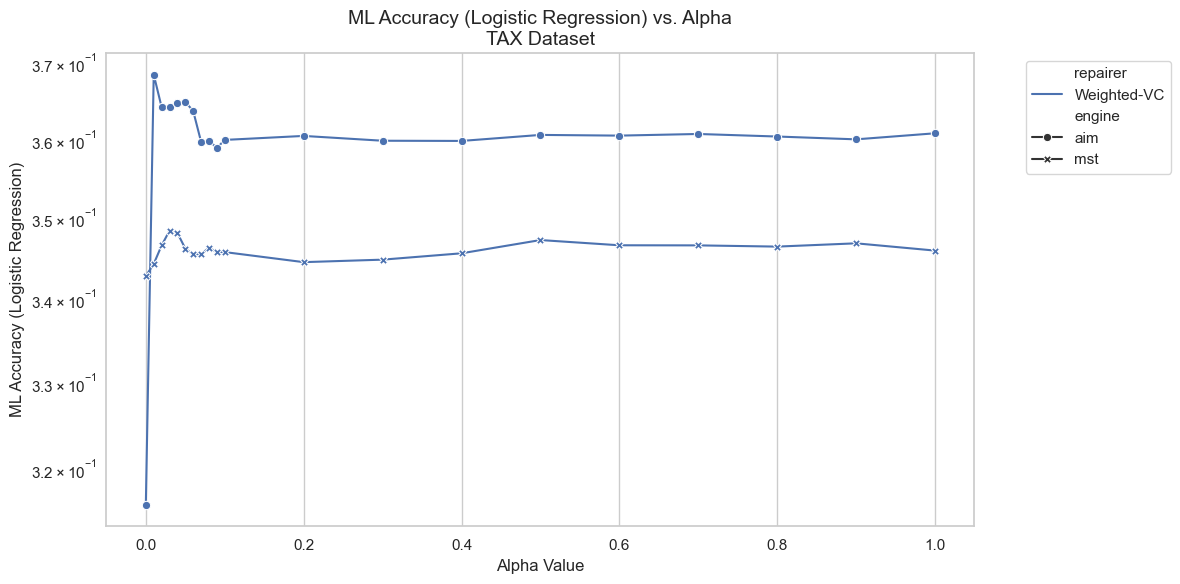

In [13]:
metrics = {
    'deletion_ratio_ratio': 'Deletion Ratio',
    'tvd_2way_repaired_avg': 'Total Variation Distance (TVD)',
    'marginals_error_repaired_avg': 'Marginal Error',
    'runtime_repairing': 'Repair Runtime (seconds)',
    'loss_function_repaired_total': 'Total Loss Function Value',
    'ml_accuracy_repaired_logistic_regression': 'ML Accuracy (Logistic Regression)'
}

def plot_metric_vs_alpha(dataset_name, metric_col, metric_title):
    ds_df = df[(df['dataset'] == dataset_name) & (df['alpha'].notna()) & (df['repairer'] == 'Weighted-VC')].copy()
    if ds_df.empty:
        return
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=ds_df, x='alpha', y=metric_col, hue='repairer', style='engine', markers=True, dashes=False)
    plt.title(f"{metric_title} vs. Alpha\n{dataset_name.upper()} Dataset", fontsize=14)
    plt.xlabel("Alpha Value", fontsize=12)
    plt.ylabel(metric_title, fontsize=12)
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

datasets = df['dataset'].dropna().unique()
for ds in datasets:
    print(f"\n{'='*50}")
    print(f"Dataset: {ds.upper()}")
    print(f"{'='*50}\n")
    for m_col, m_title in metrics.items():
        if m_col in df.columns:
            plot_metric_vs_alpha(ds, m_col, m_title)
